In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Reload modules to pick up changes
import importlib
import sys

# Remove cached modules
for module in list(sys.modules.keys()):
    if 'InterventionalPFN' in module or 'SimplePFN' in module:
        del sys.modules[module]

# Now import fresh
from InterventionalPFN_sklearn import InterventionalPFNSklearn
from SimplePFN_sklearn import SimplePFNSklearn
from sklearn.ensemble import RandomForestRegressor
from src.priordata_processing.BasicProcessing import BasicProcessing
import torch
from src.priors.causal_prior.noise_distributions.ResamplingDist import ResamplingDist


In [3]:
config_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/configs/basic.yaml"
checkpoint_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/checkpoints/simple_pfn_16635966.0/step_20000.pt"

intpfn = InterventionalPFNSklearn(
    config_path=config_path,
    checkpoint_path=checkpoint_path,
    n_estimators = 1,
    verbose=True,  # Enable verbose mode to see what's being loaded
    max_n_train = 600,
)

# Now the config should load properly with the fixed load() method
intpfn.load(override_kwargs={
    "num_features": 50  # Adjust based on your data (50 total - 1 target)
})

config_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/configs/basic.yaml"
checkpoint_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/checkpoints/simple_pfn_16631563.0/step_32000.pt"

obspfn = SimplePFNSklearn(
    config_path=config_path,
    checkpoint_path=checkpoint_path,
    n_estimators = 1,
    max_n_train = 600,
)
obspfn.load(override_kwargs={
    "num_features": 50  # Adjust based on your data (50 total - 1 target)
})


# Processor should match the config: 50 features (excluding target, including intervention column)
processor = BasicProcessing(
    n_features=49,
    max_n_features=49,
    n_train_samples = 500,
    max_n_train_samples=500,
    n_test_samples=500,
    max_n_test_samples=500,
    dropout_prob=0.0,
    target_feature=2,
    intervened_feature=0,
    negative_one_one_scaling=True,
    standardize=True,
    yeo_johnson=False,
    remove_outliers=True,
    outlier_quantile=0.95,
    shuffle_samples=False,
    shuffle_features=False,
    eps = 1e-8
)



[InterventionalPFNSklearn] Loading with config_path: /Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/configs/basic.yaml
[InterventionalPFNSklearn] verbose=True
[InterventionalPFNSklearn] Config loaded. Top-level keys: ['experiment_name', 'description', 'scm_config', 'dataset_config', 'preprocessing_config', 'model_config', 'training_config']
[InterventionalPFNSklearn] Loaded model_kwargs from config: {'num_features': 50, 'd_model': 256, 'depth': 6, 'heads_feat': 4, 'heads_samp': 4, 'dropout': 0.1, 'output_dim': 1, 'hidden_mult': 2, 'normalize_features': False}
[InterventionalPFNSklearn] BarDistribution enabled with 1000 bars
[InterventionalPFNSklearn] Model output_dim set to 1004
[InterventionalPFNSklearn] Building InterventionalPFN with kwargs: {'num_features': 50, 'd_model': 256, 'depth': 6, 'heads_feat': 4, 'heads_samp': 4, 'dropout': 0.1, 'output_dim': 1004, 'hidden_mult': 2, 'normalize_features': False}
[InterventionalPFNSklearn] Loading checkpoint from /

### Three variables, no hidden confounder

In [4]:
%cd /Users/arikreuter/Documents/PhD/CausalPriorFitting/src

/Users/arikreuter/Documents/PhD/CausalPriorFitting/src


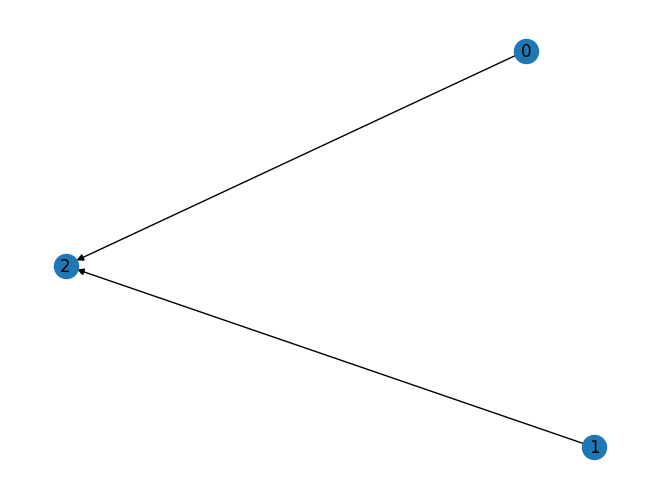

MODEL COMPARISON: Training Error, Test Error, Variance, and Entropy

--- Random Forest ---
  Train MSE:      0.244723
  Test MSE:       0.269143
  Mean Variance:  0.030182
  Mean Entropy:   -inf (Gaussian approx)

--- Observational PFN ---


/var/folders/ng/4_7_0hz56vnfj1yd8btkt5h80007z9/T/ipykernel_92185/629215991.py:109: RuntimeWarning: divide by zero encountered in log
  rf_entropy_approx = 0.5 * np.log(2 * np.pi * np.e * rf_variance)


  Train MSE:      0.216600
  Test MSE:       0.244471
  Mean Variance:  0.150131
  Mean Entropy:   0.439546

--- Interventional PFN ---
[SimplePFNSklearn] Initial k-means with k=1
[SimplePFNSklearn] Initial k-means with k=1
[SimplePFNSklearn] Initial k-means with k=1
  Train MSE:      0.170993
  Test MSE:       0.213120
  Mean Variance:  0.168141
  Mean Entropy:   0.376952

SUMMARY
Method               Train MSE       Test MSE        Mean Var        Mean Entropy   
--------------------------------------------------------------------------------
Random Forest        0.244723        0.269143        0.030182        -inf           
Obs PFN              0.216600        0.244471        0.150131        0.439546       
Int PFN              0.170993        0.213120        0.168141        0.376952       
  Train MSE:      0.170993
  Test MSE:       0.213120
  Mean Variance:  0.168141
  Mean Entropy:   0.376952

SUMMARY
Method               Train MSE       Test MSE        Mean Var        Mean Ent

In [5]:
from src.priors.causal_prior.causal_graph.GraphSampler import GraphSampler
from src.priors.causal_prior.mechanisms.SampleMLPMechanism import SampleMLPMechanism
from src.priors.causal_prior.noise_distributions.MixedDist import MixedDist
from src.priors.causal_prior.causal_graph.CausalDAG import CausalDAG
from src.priors.causal_prior.scm.SCM import SCM
from src.priors.causal_prior.noise_distributions.NormalDistribution import NormalDistribution
from src.priors.causal_prior.mechanisms.LinearMechanism import LinearMechanism
import numpy as np

NUM_NODES = 3
p = 0.5 
SEED = 42
NOISE_STD = 0.1
BATCH_SIZE = 1000

# graph
graph_sampler = GraphSampler(seed=SEED)
graph = graph_sampler.sample_dag(
    num_nodes=NUM_NODES,
    p=p,
)

new_edges = [(1, 2), 
             #(1, 0), 
             (0, 2)]
graph.clear_edges()
graph.add_edges_from(new_edges)

causal_dag = CausalDAG(
    g=graph,
    check_acyclic=True
)

causal_dag.draw()

# mechanisms 
mechanisms = {}

mechanisms[2] = LinearMechanism(
        input_dim = 2,

    weights = [1.0, 1.0],
    nonlinearity= lambda x: x
)

# noise distributions

exogenous_variables = causal_dag.exogenous_variables()
endogenous_variables = causal_dag.endogenous_variables()

exo_noise = {}
for var in exogenous_variables:
    exo_noise[var] = NormalDistribution(mean = 0, std = 1)

endo_noise = {}
for var in endogenous_variables:
    endo_noise[var]  = NormalDistribution(mean = 0, std = 1)


scm = SCM(
    dag = causal_dag,
    mechanisms = mechanisms,
    exogenous_noise = exo_noise,
    endogenous_noise = endo_noise,
    use_exogenous_mechanisms=False
)

scm.sample_exogenous(num_samples=BATCH_SIZE)
scm.sample_endogenous(num_samples=BATCH_SIZE)

r = scm.propagate(num_samples=BATCH_SIZE)

N_train = r[0].shape[0]//2
N_test = r[0].shape[0] - N_train 

r_train = {k: v[:N_train].reshape(-1, 1) for k, v in r.items()}
r_test = {k: v[N_train:].reshape(-1, 1) for k, v in r.items()}


X_train, T_train, Y_train, X_test, T_test, Y_test = processor.process_from_splits(r_train, r_test)

XT_train = torch.cat([X_train, T_train], dim=1)
XT_test = torch.cat([X_test, T_test], dim=1) 

print("="*80)
print("MODEL COMPARISON: Training Error, Test Error, Variance, and Entropy")
print("="*80)

# ============= RANDOM FOREST =============
print("\n--- Random Forest ---")
rf = RandomForestRegressor(n_estimators=10)
rf.fit(XT_train.numpy(), Y_train.numpy().ravel())

# Train predictions and error
rf_preds_train = torch.tensor(rf.predict(XT_train.numpy()))
rf_mse_train = torch.mean((Y_train.reshape(-1,1) - rf_preds_train)**2)

# Test predictions and error
rf_preds = torch.tensor(rf.predict(XT_test.numpy()))
rf_mse = torch.mean((Y_test.reshape(-1,1) - rf_preds)**2)

# Compute RF uncertainty using ensemble variance (on test set)
rf_tree_preds = np.array([tree.predict(XT_test.numpy()) for tree in rf.estimators_])  # (n_estimators, M)
rf_variance = np.var(rf_tree_preds, axis=0)  # Variance across trees
rf_mean_var = np.mean(rf_variance)

# Compute approximate entropy from ensemble (assuming Gaussian approximation)
# H ≈ 0.5 * log(2πe * variance)
rf_entropy_approx = 0.5 * np.log(2 * np.pi * np.e * rf_variance)
rf_mean_entropy = np.mean(rf_entropy_approx)

print(f"  Train MSE:      {rf_mse_train:.6f}")
print(f"  Test MSE:       {rf_mse:.6f}")
print(f"  Mean Variance:  {rf_mean_var:.6f}")
print(f"  Mean Entropy:   {rf_mean_entropy:.6f} (Gaussian approx)")

# ============= OBSERVATIONAL PFN =============
print("\n--- Observational PFN ---")

# Train predictions and error
obspfn_preds_train = obspfn.predict(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_train.numpy(),
    prediction_type="mean"
)
obspfn_mse_train = torch.mean((Y_train.reshape(-1,1) - torch.tensor(obspfn_preds_train))**2)

# Test predictions and error
obspfn_preds = obspfn.predict(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_test.numpy(),
    prediction_type="mean"
)
obspfn_mse = torch.mean((Y_test.reshape(-1,1) - torch.tensor(obspfn_preds))**2)

# Compute variance and entropy for ObsPFN (on test set)
obspfn_variance = obspfn.predict_variance(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_test.numpy(),
    num_samples=1000
)
obspfn_mean_var = np.mean(obspfn_variance)

obspfn_entropy = obspfn.predict_entropy(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_test.numpy(),
    num_samples=1000
)
obspfn_mean_entropy = np.mean(obspfn_entropy)

print(f"  Train MSE:      {obspfn_mse_train:.6f}")
print(f"  Test MSE:       {obspfn_mse:.6f}")
print(f"  Mean Variance:  {obspfn_mean_var:.6f}")
print(f"  Mean Entropy:   {obspfn_mean_entropy:.6f}")

# ============= INTERVENTIONAL PFN =============
print("\n--- Interventional PFN ---")
X_obs_ext = torch.cat([X_train, torch.zeros_like(T_train)], dim=1)
X_intv_ext = torch.cat([X_test, T_test], dim=1)

# Train predictions and error
intpfn_preds_train = intpfn.predict(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs_ext.numpy(),
    T_intv= T_train.numpy(),
    prediction_type="mean"
)
intpfn_mse_train = torch.mean((Y_train.reshape(-1,1) - torch.tensor(intpfn_preds_train))**2)

# Test predictions and error
intpfn_preds = intpfn.predict(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy(),
    prediction_type="mean"
)
intpfn_mse = torch.mean((Y_test.reshape(-1,1) - torch.tensor(intpfn_preds))**2)

# Compute variance and entropy for IntPFN (on test set)
intpfn_variance = intpfn.predict_variance(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy(),
    num_samples=1000
)
intpfn_mean_var = np.mean(intpfn_variance)

intpfn_entropy = intpfn.predict_entropy(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy(),
    num_samples=1000
)
intpfn_mean_entropy = np.mean(intpfn_entropy)

print(f"  Train MSE:      {intpfn_mse_train:.6f}")
print(f"  Test MSE:       {intpfn_mse:.6f}")
print(f"  Mean Variance:  {intpfn_mean_var:.6f}")
print(f"  Mean Entropy:   {intpfn_mean_entropy:.6f}")

# ============= SUMMARY =============
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"{'Method':<20} {'Train MSE':<15} {'Test MSE':<15} {'Mean Var':<15} {'Mean Entropy':<15}")
print("-"*80)
print(f"{'Random Forest':<20} {rf_mse_train.item():<15.6f} {rf_mse.item():<15.6f} {rf_mean_var:<15.6f} {rf_mean_entropy:<15.6f}")
print(f"{'Obs PFN':<20} {obspfn_mse_train.item():<15.6f} {obspfn_mse.item():<15.6f} {obspfn_mean_var:<15.6f} {obspfn_mean_entropy:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_train.item():<15.6f} {intpfn_mse.item():<15.6f} {intpfn_mean_var:<15.6f} {intpfn_mean_entropy:<15.6f}")
print("="*80)


# Simpe observational prediction

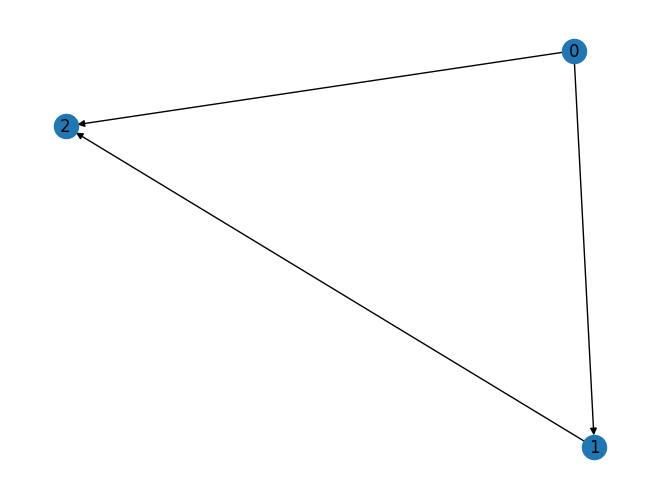

MODEL COMPARISON: Training Error, Test Error, Variance, and Entropy

--- Random Forest ---
  Train MSE:      0.203667
  Test MSE:       0.185364
  Mean Variance:  0.014682
  Mean Entropy:   -inf (Gaussian approx)

--- Observational PFN ---


/var/folders/ng/4_7_0hz56vnfj1yd8btkt5h80007z9/T/ipykernel_92185/1005155500.py:117: RuntimeWarning: divide by zero encountered in log
  rf_entropy_approx = 0.5 * np.log(2 * np.pi * np.e * rf_variance)


  Train MSE:      0.197135
  Test MSE:       0.189186
  Mean Variance:  0.118651
  Mean Entropy:   0.324041

--- Interventional PFN ---
[SimplePFNSklearn] Initial k-means with k=1
[SimplePFNSklearn] Initial k-means with k=1
[SimplePFNSklearn] Initial k-means with k=1
  Train MSE:      0.187837
  Test MSE:       0.194874
  Mean Variance:  0.064175
  Mean Entropy:   -0.313991

SUMMARY
Method               Train MSE       Test MSE        Mean Var        Mean Entropy   
--------------------------------------------------------------------------------
Random Forest        0.203667        0.185364        0.014682        -inf           
Obs PFN              0.197135        0.189186        0.118651        0.324041       
Int PFN              0.187837        0.194874        0.064175        -0.313991      
  Train MSE:      0.187837
  Test MSE:       0.194874
  Mean Variance:  0.064175
  Mean Entropy:   -0.313991

SUMMARY
Method               Train MSE       Test MSE        Mean Var        Mean E

In [6]:
from src.priors.causal_prior.causal_graph.GraphSampler import GraphSampler
from src.priors.causal_prior.mechanisms.SampleMLPMechanism import SampleMLPMechanism
from src.priors.causal_prior.noise_distributions.MixedDist import MixedDist
from src.priors.causal_prior.causal_graph.CausalDAG import CausalDAG
from src.priors.causal_prior.scm.SCM import SCM
from src.priors.causal_prior.noise_distributions.NormalDistribution import NormalDistribution
from src.priors.causal_prior.mechanisms.LinearMechanism import LinearMechanism
import numpy as np

NUM_NODES = 3
p = 0.5 
SEED = 42
NOISE_STD = 0.1
BATCH_SIZE = 1000

# graph
graph_sampler = GraphSampler(seed=SEED)
graph = graph_sampler.sample_dag(
    num_nodes=NUM_NODES,
    p=p,
)

new_edges = [(1, 2), 
             (0, 1), 
             (0, 2)]
graph.clear_edges()
graph.add_edges_from(new_edges)

causal_dag = CausalDAG(
    g=graph,
    check_acyclic=True
)

causal_dag.draw()

# mechanisms 
mechanisms = {}

mechanisms[2] = LinearMechanism(
        input_dim = 2,

    weights = [1.0, 1.0],
    nonlinearity= lambda x: x
)

mechanisms[1] = LinearMechanism(
        input_dim = 1,

    weights = [1.0],
    nonlinearity= lambda x: x
)


# noise distributions

exogenous_variables = causal_dag.exogenous_variables()
endogenous_variables = causal_dag.endogenous_variables()

exo_noise = {}
for var in exogenous_variables:
    exo_noise[var] = NormalDistribution(mean = 0, std = 1)

endo_noise = {}
for var in endogenous_variables:
    endo_noise[var]  = NormalDistribution(mean = 0, std = 1)


scm = SCM(
    dag = causal_dag,
    mechanisms = mechanisms,
    exogenous_noise = exo_noise,
    endogenous_noise = endo_noise,
    use_exogenous_mechanisms=False
)

scm.sample_exogenous(num_samples=BATCH_SIZE)
scm.sample_endogenous(num_samples=BATCH_SIZE)

r = scm.propagate(num_samples=BATCH_SIZE)

N_train = r[0].shape[0]//2
N_test = r[0].shape[0] - N_train 

r_train = {k: v[:N_train].reshape(-1, 1) for k, v in r.items()}
r_test = {k: v[N_train:].reshape(-1, 1) for k, v in r.items()}


X_train, T_train, Y_train, X_test, T_test, Y_test = processor.process_from_splits(r_train, r_test)

XT_train = torch.cat([X_train, T_train], dim=1)
XT_test = torch.cat([X_test, T_test], dim=1) 

print("="*80)
print("MODEL COMPARISON: Training Error, Test Error, Variance, and Entropy")
print("="*80)

# ============= RANDOM FOREST =============
print("\n--- Random Forest ---")
rf = RandomForestRegressor(n_estimators=10)
rf.fit(XT_train.numpy(), Y_train.numpy().ravel())

# Train predictions and error
rf_preds_train = torch.tensor(rf.predict(XT_train.numpy()))
rf_mse_train = torch.mean((Y_train.reshape(-1,1) - rf_preds_train)**2)

# Test predictions and error
rf_preds = torch.tensor(rf.predict(XT_test.numpy()))
rf_mse = torch.mean((Y_test.reshape(-1,1) - rf_preds)**2)

# Compute RF uncertainty using ensemble variance (on test set)
rf_tree_preds = np.array([tree.predict(XT_test.numpy()) for tree in rf.estimators_])  # (n_estimators, M)
rf_variance = np.var(rf_tree_preds, axis=0)  # Variance across trees
rf_mean_var = np.mean(rf_variance)

# Compute approximate entropy from ensemble (assuming Gaussian approximation)
# H ≈ 0.5 * log(2πe * variance)
rf_entropy_approx = 0.5 * np.log(2 * np.pi * np.e * rf_variance)
rf_mean_entropy = np.mean(rf_entropy_approx)

print(f"  Train MSE:      {rf_mse_train:.6f}")
print(f"  Test MSE:       {rf_mse:.6f}")
print(f"  Mean Variance:  {rf_mean_var:.6f}")
print(f"  Mean Entropy:   {rf_mean_entropy:.6f} (Gaussian approx)")

# ============= OBSERVATIONAL PFN =============
print("\n--- Observational PFN ---")

# Train predictions and error
obspfn_preds_train = obspfn.predict(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_train.numpy(),
    prediction_type="mean"
)
obspfn_mse_train = torch.mean((Y_train.reshape(-1,1) - torch.tensor(obspfn_preds_train))**2)

# Test predictions and error
obspfn_preds = obspfn.predict(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_test.numpy(),
    prediction_type="mean"
)
obspfn_mse = torch.mean((Y_test.reshape(-1,1) - torch.tensor(obspfn_preds))**2)

# Compute variance and entropy for ObsPFN (on test set)
obspfn_variance = obspfn.predict_variance(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_test.numpy(),
    num_samples=1000
)
obspfn_mean_var = np.mean(obspfn_variance)

obspfn_entropy = obspfn.predict_entropy(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_test.numpy(),
    num_samples=1000
)
obspfn_mean_entropy = np.mean(obspfn_entropy)

print(f"  Train MSE:      {obspfn_mse_train:.6f}")
print(f"  Test MSE:       {obspfn_mse:.6f}")
print(f"  Mean Variance:  {obspfn_mean_var:.6f}")
print(f"  Mean Entropy:   {obspfn_mean_entropy:.6f}")

# ============= INTERVENTIONAL PFN =============
print("\n--- Interventional PFN ---")
X_obs_ext = torch.cat([X_train, torch.zeros_like(T_train)], dim=1)
X_intv_ext = torch.cat([X_test, T_test], dim=1)

# Train predictions and error
intpfn_preds_train = intpfn.predict(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs_ext.numpy(),
    T_intv= T_train.numpy(),
    prediction_type="mean"
)
intpfn_mse_train = torch.mean((Y_train.reshape(-1,1) - torch.tensor(intpfn_preds_train))**2)

# Test predictions and error
intpfn_preds = intpfn.predict(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy(),
    prediction_type="mean"
)
intpfn_mse = torch.mean((Y_test.reshape(-1,1) - torch.tensor(intpfn_preds))**2)

# Compute variance and entropy for IntPFN (on test set)
intpfn_variance = intpfn.predict_variance(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy(),
    num_samples=1000
)
intpfn_mean_var = np.mean(intpfn_variance)

intpfn_entropy = intpfn.predict_entropy(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy(),
    num_samples=1000
)
intpfn_mean_entropy = np.mean(intpfn_entropy)

print(f"  Train MSE:      {intpfn_mse_train:.6f}")
print(f"  Test MSE:       {intpfn_mse:.6f}")
print(f"  Mean Variance:  {intpfn_mean_var:.6f}")
print(f"  Mean Entropy:   {intpfn_mean_entropy:.6f}")

# ============= SUMMARY =============
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"{'Method':<20} {'Train MSE':<15} {'Test MSE':<15} {'Mean Var':<15} {'Mean Entropy':<15}")
print("-"*80)
print(f"{'Random Forest':<20} {rf_mse_train.item():<15.6f} {rf_mse.item():<15.6f} {rf_mean_var:<15.6f} {rf_mean_entropy:<15.6f}")
print(f"{'Obs PFN':<20} {obspfn_mse_train.item():<15.6f} {obspfn_mse.item():<15.6f} {obspfn_mean_var:<15.6f} {obspfn_mean_entropy:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_train.item():<15.6f} {intpfn_mse.item():<15.6f} {intpfn_mean_var:<15.6f} {intpfn_mean_entropy:<15.6f}")
print("="*80)


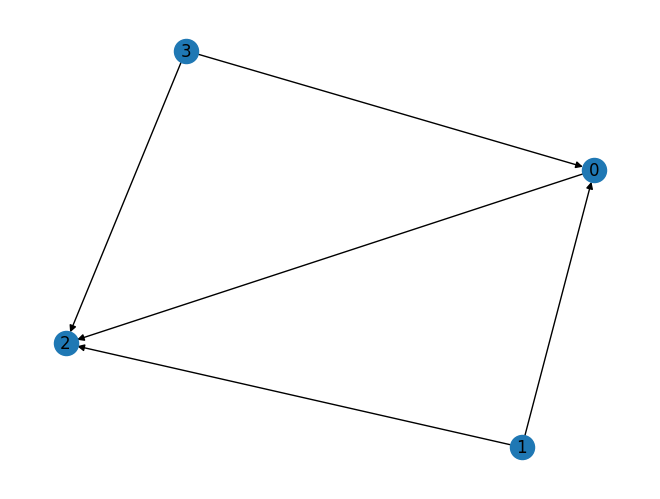

MODEL COMPARISON: MSE, Variance, and Entropy

--- Random Forest ---
  MSE:            0.185445
  Mean Variance:  0.011878
  Mean Entropy:   -0.936117 (Gaussian approx)

--- Observational PFN ---
  MSE:            0.186016
  Mean Variance:  0.112042
  Mean Entropy:   0.300468

--- Interventional PFN ---
[SimplePFNSklearn] Initial k-means with k=1
  MSE:            0.186016
  Mean Variance:  0.112042
  Mean Entropy:   0.300468

--- Interventional PFN ---
[SimplePFNSklearn] Initial k-means with k=1
  MSE:            0.182069
  Mean Variance:  0.075627
  Mean Entropy:   -0.220454

SUMMARY
Method               MSE             Mean Variance   Mean Entropy   
--------------------------------------------------------------------------------
Random Forest        0.185445        0.011878        -0.936117      
Obs PFN              0.186016        0.112042        0.300468       
Int PFN              0.182069        0.075627        -0.220454      
  MSE:            0.182069
  Mean Variance:  0.0756

In [7]:
from src.priors.causal_prior.causal_graph.GraphSampler import GraphSampler
from src.priors.causal_prior.mechanisms.SampleMLPMechanism import SampleMLPMechanism
from src.priors.causal_prior.noise_distributions.MixedDist import MixedDist
from src.priors.causal_prior.causal_graph.CausalDAG import CausalDAG
from src.priors.causal_prior.scm.SCM import SCM
from src.priors.causal_prior.noise_distributions.NormalDistribution import NormalDistribution
from src.priors.causal_prior.mechanisms.LinearMechanism import LinearMechanism
import numpy as np

NUM_NODES = 4
p = 0.5 
SEED = 42
NOISE_STD = 0.1
BATCH_SIZE = 1000

# graph
graph_sampler = GraphSampler(seed=SEED)
graph = graph_sampler.sample_dag(
    num_nodes=NUM_NODES,
    p=p,
)

new_edges = [(1, 2), 
             (1, 0), 
            (3, 0),
            (3,2),
            (0,2)
            ]
graph.clear_edges()
graph.add_edges_from(new_edges)

causal_dag = CausalDAG(
    g=graph,
    check_acyclic=True
)



causal_dag.draw()

# mechanisms 
mechanisms = {}

mechanisms[2] = LinearMechanism(
        input_dim = 3,

    weights = [1.0, 1.0, 1.0],
    nonlinearity= lambda x: x
)

mechanisms[1] = LinearMechanism(
        input_dim = 1,

    weights = [1.0],
    nonlinearity= lambda x: x
)

mechanisms[0] = LinearMechanism(
        input_dim = 2,

    weights = [1.0, 1.0],
    nonlinearity= lambda x: x 
)

mechanisms[3] = LinearMechanism(
        input_dim = 1,

    weights = [1.0],
    nonlinearity= lambda x: x
)



# noise distributions

exogenous_variables = causal_dag.exogenous_variables()
endogenous_variables = causal_dag.endogenous_variables()

exo_noise = {}
for var in exogenous_variables:
    exo_noise[var] = NormalDistribution(mean = 0, std = 1)

endo_noise = {}
for var in endogenous_variables:
    endo_noise[var]  = NormalDistribution(mean = 0, std = 1)


scm = SCM(
    dag = causal_dag,
    mechanisms = mechanisms,
    exogenous_noise = exo_noise,
    endogenous_noise = endo_noise,
    use_exogenous_mechanisms=False
)

scm.sample_exogenous(num_samples=BATCH_SIZE)
scm.sample_endogenous(num_samples=BATCH_SIZE)

r = scm.propagate(num_samples=BATCH_SIZE)

N_train = r[0].shape[0]//2
N_test = r[0].shape[0] - N_train 

r_train = {k: v[:N_train].reshape(-1, 1) for k, v in r.items()}
r_test = {k: v[N_train:].reshape(-1, 1) for k, v in r.items()}


X_train, T_train, Y_train, X_test, T_test, Y_test = processor.process_from_splits(r_train, r_test)

XT_train = torch.cat([X_train, T_train], dim=1)
XT_test = torch.cat([X_test, T_test], dim=1) 

print("="*80)
print("MODEL COMPARISON: MSE, Variance, and Entropy")
print("="*80)

# ============= RANDOM FOREST =============
print("\n--- Random Forest ---")
rf = RandomForestRegressor(n_estimators=10)
rf.fit(XT_train.numpy(), Y_train.numpy().ravel())
rf_preds = torch.tensor(rf.predict(XT_test.numpy()))
rf_mse = torch.mean((Y_test.reshape(-1,1) - rf_preds)**2)

# Compute RF uncertainty using ensemble variance
rf_tree_preds = np.array([tree.predict(XT_test.numpy()) for tree in rf.estimators_])  # (n_estimators, M)
rf_variance = np.var(rf_tree_preds, axis=0)  # Variance across trees
rf_mean_var = np.mean(rf_variance)

# Compute approximate entropy from ensemble (assuming Gaussian approximation)
# H ≈ 0.5 * log(2πe * variance)
rf_entropy_approx = 0.5 * np.log(2 * np.pi * np.e * rf_variance)
rf_mean_entropy = np.mean(rf_entropy_approx)

print(f"  MSE:            {rf_mse:.6f}")
print(f"  Mean Variance:  {rf_mean_var:.6f}")
print(f"  Mean Entropy:   {rf_mean_entropy:.6f} (Gaussian approx)")

# ============= OBSERVATIONAL PFN =============
print("\n--- Observational PFN ---")
obspfn_preds = obspfn.predict(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_test.numpy(),
    prediction_type="mean"
)
obspfn_mse = torch.mean((Y_test.reshape(-1,1) - torch.tensor(obspfn_preds))**2)

# Compute variance and entropy for ObsPFN
obspfn_variance = obspfn.predict_variance(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_test.numpy(),
    num_samples=1000
)
obspfn_mean_var = np.mean(obspfn_variance)

obspfn_entropy = obspfn.predict_entropy(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_test.numpy(),
    num_samples=1000
)
obspfn_mean_entropy = np.mean(obspfn_entropy)

print(f"  MSE:            {obspfn_mse:.6f}")
print(f"  Mean Variance:  {obspfn_mean_var:.6f}")
print(f"  Mean Entropy:   {obspfn_mean_entropy:.6f}")

# ============= INTERVENTIONAL PFN =============
print("\n--- Interventional PFN ---")
X_obs_ext = torch.cat([X_train, torch.zeros_like(T_train)], dim=1)
X_intv_ext = torch.cat([X_test, T_test], dim=1)

intpfn_preds = intpfn.predict(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy(),
    prediction_type="mean"
)
intpfn_mse = torch.mean((Y_test.reshape(-1,1) - torch.tensor(intpfn_preds))**2)

# Compute variance and entropy for IntPFN
intpfn_variance = intpfn.predict_variance(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy(),
    num_samples=1000
)
intpfn_mean_var = np.mean(intpfn_variance)

intpfn_entropy = intpfn.predict_entropy(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy(),
    num_samples=1000
)
intpfn_mean_entropy = np.mean(intpfn_entropy)

print(f"  MSE:            {intpfn_mse:.6f}")
print(f"  Mean Variance:  {intpfn_mean_var:.6f}")
print(f"  Mean Entropy:   {intpfn_mean_entropy:.6f}")

# ============= SUMMARY =============
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"{'Method':<20} {'MSE':<15} {'Mean Variance':<15} {'Mean Entropy':<15}")
print("-"*80)
print(f"{'Random Forest':<20} {rf_mse.item():<15.6f} {rf_mean_var:<15.6f} {rf_mean_entropy:<15.6f}")
print(f"{'Obs PFN':<20} {obspfn_mse.item():<15.6f} {obspfn_mean_var:<15.6f} {obspfn_mean_entropy:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse.item():<15.6f} {intpfn_mean_var:<15.6f} {intpfn_mean_entropy:<15.6f}")
print("="*80)


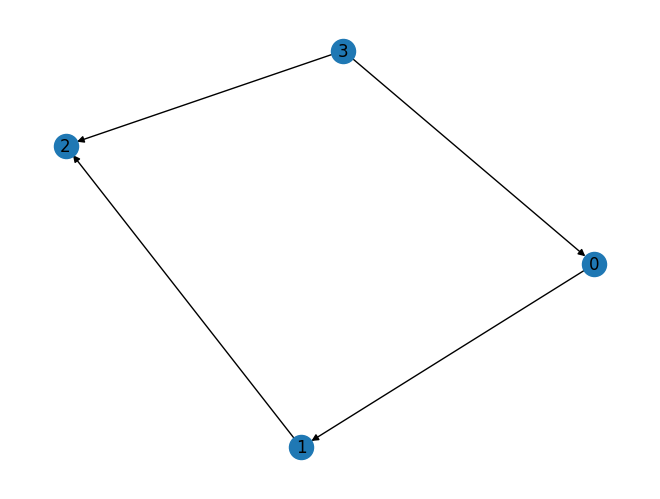

KeyError: 1

In [11]:
from src.priors.causal_prior.causal_graph.GraphSampler import GraphSampler
from src.priors.causal_prior.mechanisms.SampleMLPMechanism import SampleMLPMechanism
from src.priors.causal_prior.noise_distributions.MixedDist import MixedDist
from src.priors.causal_prior.causal_graph.CausalDAG import CausalDAG
from src.priors.causal_prior.scm.SCM import SCM
from src.priors.causal_prior.noise_distributions.NormalDistribution import NormalDistribution
from src.priors.causal_prior.mechanisms.LinearMechanism import LinearMechanism
import numpy as np


NOISE_STD   = 0.3   # smaller noise so confounding really dominates
BATCH_SIZE  = 1000

graph_sampler = GraphSampler(seed=SEED)
graph = graph_sampler.sample_dag(
    num_nodes=NUM_NODES,
    p=0.0,  # not used, we overwrite edges anyway
)

# define edges explicitly for clarity
frontdoor_edges = [
    (3, 0),  # U -> T
    (0, 1),  # T -> X
    (1, 2),  # X -> Y
    (3, 2),  # U -> Y
]

graph.clear_edges()
graph.add_edges_from(frontdoor_edges)

causal_dag = CausalDAG(
    g=graph,
    check_acyclic=True
)

causal_dag.draw()  # should show U -> T -> X -> Y and U -> Y

mechanisms = {}

# T = 3 * U + ε_T   (strong confounding)
mechanisms[0] = LinearMechanism(
    input_dim=1,      # U
    weights=[3.0],
    nonlinearity=lambda x: x,
)

# X = 1.0 * T + ε_X
mechanisms[1] = LinearMechanism(
    input_dim=1,      # T
    weights=[1.0],
    nonlinearity=lambda x: x,
)

# Y = 0.5 * X + 8.0 * U + ε_Y   (U dominates Y)
mechanisms[2] = LinearMechanism(
    input_dim=2,      # (X, U)
    weights=[0.5, 8.0],
    nonlinearity=lambda x: x,
)

# No mechanism[3] -> U is pure exogenous.

# U is exogenous, no mechanism[3].

# noise distributions
# Observational noise
exo_noise_obs = {}
for var in causal_dag.exogenous_variables():
    # Only node 3 (U) is exogenous in the observational DAG
    exo_noise_obs[var] = NormalDistribution(mean=0.0, std=1.0)  # U ~ N(0,1)

endo_noise_obs = {}
for var in causal_dag.endogenous_variables():
    endo_noise_obs[var] = NormalDistribution(mean=0.0, std=NOISE_STD)
scm = SCM(
    dag = causal_dag,
    mechanisms = mechanisms,
    exogenous_noise = exo_noise,
    endogenous_noise = endo_noise,
    use_exogenous_mechanisms=False
)


scm.sample_exogenous(num_samples=BATCH_SIZE//2)
scm.sample_endogenous(num_samples=BATCH_SIZE//2)

r = scm.propagate(num_samples=BATCH_SIZE//2)


obs0_raw = scm.propagate(num_samples=BATCH_SIZE//2)
        # Reshape from (N,) to (N,1) for BasicProcessing compatibility
obs0 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in obs0_raw.items()}




scm.sample_exogenous(num_samples=BATCH_SIZE//2) #sample observational data again. 
scm.sample_endogenous(num_samples=BATCH_SIZE//2) #sample observational data again. 

obs1_raw = scm.propagate(num_samples=BATCH_SIZE//2)  # fresh observational batch (test-size)

# Collect observational samples for the chosen intervention node (marginal)

intervention_node = 0
intervention_samples = obs1_raw[intervention_node]

# Resampling distribution over observational marginal (without replacement)
interventional_dist = ResamplingDist(intervention_samples)


scm.intervene(node = intervention_node) # intervene on the chosen node

# Replace the noise distribution for the intervened node with its observational marginal
if intervention_node in scm.dag.endogenous_variables():
    print("endo_node")
    scm.endogenous_noise[intervention_node] = interventional_dist
if intervention_node in scm.dag.exogenous_variables():
    scm.exogenous_noise[intervention_node] = interventional_dist
    print("exo_node")

# Sample new noise for interventional scenario
# Sample new noise for interventional scenario
scm.sample_exogenous(num_samples=BATCH_SIZE//2)
scm.sample_endogenous(num_samples=BATCH_SIZE//2)

interv1_raw = scm.propagate(num_samples=BATCH_SIZE//2)  # interventional data (post-intervention)
# Reshape from (N,) to (N,1) for BasicProcessing compatibility
interv1 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in interv1_raw.items()}

N_train = r[0].shape[0]//2
N_test = r[0].shape[0] - N_train 

#obs0 = {k: v[:N_train].reshape(-1, 1) for k, v in obs0.items()}
interv1 = {k: v.reshape(-1, 1) for k, v in interv1.items()}


X_train, T_train, Y_train, X_test, T_test, Y_test = processor.process_from_splits(obs0, interv1)

XT_train = torch.cat([X_train, T_train], dim=1)
XT_test = torch.cat([X_test, T_test], dim=1) 


print("="*80)
print("MODEL COMPARISON: Training Error, Test Error, Variance, and Entropy")
print("="*80)

# ============= RANDOM FOREST =============
print("\n--- Random Forest ---")
rf = RandomForestRegressor(n_estimators=10)
rf.fit(XT_train.numpy(), Y_train.numpy().ravel())

# Train predictions and error
rf_preds_train = torch.tensor(rf.predict(XT_train.numpy()))
rf_mse_train = torch.mean((Y_train.reshape(-1,1) - rf_preds_train)**2)

# Test predictions and error
rf_preds = torch.tensor(rf.predict(XT_test.numpy()))
rf_mse = torch.mean((Y_test.reshape(-1,1) - rf_preds)**2)

# Compute RF uncertainty using ensemble variance (on test set)
rf_tree_preds = np.array([tree.predict(XT_test.numpy()) for tree in rf.estimators_])  # (n_estimators, M)
rf_variance = np.var(rf_tree_preds, axis=0)  # Variance across trees
rf_mean_var = np.mean(rf_variance)

# Compute approximate entropy from ensemble (assuming Gaussian approximation)
# H ≈ 0.5 * log(2πe * variance)
rf_entropy_approx = 0.5 * np.log(2 * np.pi * np.e * rf_variance)
rf_mean_entropy = np.mean(rf_entropy_approx)

print(f"  Train MSE:      {rf_mse_train:.6f}")
print(f"  Test MSE:       {rf_mse:.6f}")
print(f"  Mean Variance:  {rf_mean_var:.6f}")
print(f"  Mean Entropy:   {rf_mean_entropy:.6f} (Gaussian approx)")

# ============= OBSERVATIONAL PFN =============
print("\n--- Observational PFN ---")

# Train predictions and error
obspfn_preds_train = obspfn.predict(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_train.numpy(),
    prediction_type="mean"
)
obspfn_mse_train = torch.mean((Y_train.reshape(-1,1) - torch.tensor(obspfn_preds_train))**2)

# Test predictions and error
obspfn_preds = obspfn.predict(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_test.numpy(),
    prediction_type="mean"
)
obspfn_mse = torch.mean((Y_test.reshape(-1,1) - torch.tensor(obspfn_preds))**2)

# Compute variance and entropy for ObsPFN (on test set)
obspfn_variance = obspfn.predict_variance(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_test.numpy(),
    num_samples=1000
)
obspfn_mean_var = np.mean(obspfn_variance)

obspfn_entropy = obspfn.predict_entropy(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_test.numpy(),
    num_samples=1000
)
obspfn_mean_entropy = np.mean(obspfn_entropy)

print(f"  Train MSE:      {obspfn_mse_train:.6f}")
print(f"  Test MSE:       {obspfn_mse:.6f}")
print(f"  Mean Variance:  {obspfn_mean_var:.6f}")
print(f"  Mean Entropy:   {obspfn_mean_entropy:.6f}")

# ============= INTERVENTIONAL PFN =============
print("\n--- Interventional PFN ---")
X_obs_ext = torch.cat([X_train, torch.zeros_like(T_train)], dim=1)
X_intv_ext = torch.cat([X_test, T_test], dim=1)

# Train predictions and error
intpfn_preds_train = intpfn.predict(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs_ext.numpy(),
    T_intv= T_train.numpy(),
    prediction_type="mean"
)
intpfn_mse_train = torch.mean((Y_train.reshape(-1,1) - torch.tensor(intpfn_preds_train))**2)

# Test predictions and error
intpfn_preds = intpfn.predict(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy(),
    prediction_type="mean"
)
intpfn_mse = torch.mean((Y_test.reshape(-1,1) - torch.tensor(intpfn_preds))**2)

# Compute variance and entropy for IntPFN (on test set)
intpfn_variance = intpfn.predict_variance(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy(),
    num_samples=1000
)
intpfn_mean_var = np.mean(intpfn_variance)

intpfn_entropy = intpfn.predict_entropy(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy(),
    num_samples=1000
)
intpfn_mean_entropy = np.mean(intpfn_entropy)

print(f"  Train MSE:      {intpfn_mse_train:.6f}")
print(f"  Test MSE:       {intpfn_mse:.6f}")
print(f"  Mean Variance:  {intpfn_mean_var:.6f}")
print(f"  Mean Entropy:   {intpfn_mean_entropy:.6f}")

# ============= SUMMARY =============
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"{'Method':<20} {'Train MSE':<15} {'Test MSE':<15} {'Mean Var':<15} {'Mean Entropy':<15}")
print("-"*80)
print(f"{'Random Forest':<20} {rf_mse_train.item():<15.6f} {rf_mse.item():<15.6f} {rf_mean_var:<15.6f} {rf_mean_entropy:<15.6f}")
print(f"{'Obs PFN':<20} {obspfn_mse_train.item():<15.6f} {obspfn_mse.item():<15.6f} {obspfn_mean_var:<15.6f} {obspfn_mean_entropy:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_train.item():<15.6f} {intpfn_mse.item():<15.6f} {intpfn_mean_var:<15.6f} {intpfn_mean_entropy:<15.6f}")
print("="*80)
prediction_type="mean"

intpfn_mse = torch.mean((Y_test.reshape(-1,1) - torch.tensor(intpfn_preds))**2)

# Compute variance and entropy for IntPFN
intpfn_variance = intpfn.predict_variance(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy(),
    num_samples=1000
)
intpfn_mean_var = np.mean(intpfn_variance)

intpfn_entropy = intpfn.predict_entropy(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy(),
    num_samples=1000
)
intpfn_mean_entropy = np.mean(intpfn_entropy)

print(f"  MSE:            {intpfn_mse:.6f}")
print(f"  Mean Variance:  {intpfn_mean_var:.6f}")
print(f"  Mean Entropy:   {intpfn_mean_entropy:.6f}")

# ============= SUMMARY =============
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"{'Method':<20} {'MSE':<15} {'Mean Variance':<15} {'Mean Entropy':<15}")
print("-"*80)
print(f"{'Random Forest':<20} {rf_mse.item():<15.6f} {rf_mean_var:<15.6f} {rf_mean_entropy:<15.6f}")
print(f"{'Obs PFN':<20} {obspfn_mse.item():<15.6f} {obspfn_mean_var:<15.6f} {obspfn_mean_entropy:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse.item():<15.6f} {intpfn_mean_var:<15.6f} {intpfn_mean_entropy:<15.6f}")
print("="*80)


In [ ]:
X_obs_ext.shape

torch.Size([500, 50])